# Spatio-Temporal Crime Forecasting with Deep Learning
### Chicago Crime Dataset  |  LSTM + Conv-LSTM  |  Folium Maps

This notebook walks through a complete deep-learning pipeline for predicting
where and when crimes are likely to occur in Chicago.  
We go from raw CSV data all the way to trained models and interactive heat-maps.


**Dataset:** Chicago Crimes (2001 – Present)  
Source: https://data.cityofchicago.org/Public-Safety/Crimes-2001-to-Present/ijzp-q8t2

You can download a filtered slice (e.g. 2018-2023) directly from the Chicago
Open Data portal or via the Socrata API.  A direct CSV export link is provided
in the data-loading cell below.


---
## Section 1 — Install & Import Libraries

We install everything we need if it is not already present, then import it.
`folium` is used for interactive maps; `torch` handles the deep-learning side.


In [1]:
# Install required packages (run once; safe to re-run)
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

for package in ["folium", "torch", "torchvision", "pandas", "numpy",
                "matplotlib", "seaborn", "scikit-learn", "tqdm",
                "requests", "branca"]:
    try:
        __import__(package.split("[")[0])
    except ImportError:
        print(f"Installing {package} ...")
        install(package)

print("All libraries ready.")


Installing scikit-learn ...
All libraries ready.


In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from tqdm import tqdm

import folium
from folium.plugins import HeatMap, HeatMapWithTime

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device selection: use GPU if available
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")


Using device: cpu
PyTorch version: 2.10.0+cpu


---
## Section 2 — Load the Chicago Crime Dataset

**About the dataset:**  
The City of Chicago publishes every recorded crime incident since 2001.  
Each row has a date/time, crime type, location description, GPS coordinates,
arrest flag, and more.

**Download link (direct CSV export — ~2 GB for full dataset):**  
https://data.cityofchicago.org/api/views/ijzp-q8t2/rows.csv?accessType=DOWNLOAD

For this notebook we fetch a manageable slice via the Socrata API (last 500 k
rows, roughly 2020-2023).  If you already downloaded the full CSV, set
`USE_LOCAL = True` and point `LOCAL_PATH` at your file.

**Columns we care about:**
| Column | Description |
|--------|-------------|
| `Date` | When the crime occurred |
| `Primary Type` | Category (THEFT, ASSAULT, …) |
| `Latitude` / `Longitude` | GPS coordinates |
| `Arrest` | Whether an arrest was made |
| `Domestic` | Domestic-violence flag |


In [3]:
# ── Configuration ────────────────────────────────────────────────────────────
USE_LOCAL   = False          # Set True if you have the full CSV on disk
LOCAL_PATH  = "chicago_crimes.csv"

# Socrata API — fetch 500 000 recent records (no API key needed for this limit)
API_URL = (
    "https://data.cityofchicago.org/resource/ijzp-q8t2.csv"
    "?$limit=500000"
    "&$order=date%20DESC"
    "&$where=latitude%20IS%20NOT%20NULL"
)

# Load
if USE_LOCAL and os.path.exists(LOCAL_PATH):
    print("Loading from local file ...")
    df = pd.read_csv(LOCAL_PATH)
else:
    print("Fetching data from Chicago Open Data portal ...")
    print("This may take 1-3 minutes depending on your connection.")
    df = pd.read_csv(API_URL)
    df.to_csv("chicago_crimes_raw.csv", index=False)   # cache locally
    print("Saved local cache: chicago_crimes_raw.csv")

print(f"\nLoaded {len(df):,} records with {df.shape[1]} columns.")
df.head(3)


Fetching data from Chicago Open Data portal ...
This may take 1-3 minutes depending on your connection.
Saved local cache: chicago_crimes_raw.csv

Loaded 500,000 records with 22 columns.


,id,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,...,ward,community_area,fbi_code,x_coordinate,y_coordinate,year,updated_on,latitude,longitude,location
0,14200271,JK258542,2026-05-17T00:00:00.000,047XX W SUPERIOR ST,0560,ASSAULT,SIMPLE,RESIDENCE,False,False,...,28.0,25.0,08A,1144661,1904544,2026,2026-05-24T15:42:13.000,41.894082,-87.744158,"\n, \n(41.894081569, -87.744157912)"
1,14200563,JK257725,2026-05-17T00:00:00.000,100XX W OHARE ST,1330,CRIMINAL TRESPASS,TO LAND,AIRPORT PARKING LOT,False,False,...,41.0,76.0,26,1100658,1934241,2026,2026-05-24T15:42:13.000,41.976290,-87.905227,"\n, \n(41.976290414, -87.905227221)"
2,14204654,JK263704,2026-05-17T00:00:00.000,026XX W 59TH ST,2825,OTHER OFFENSE,HARASSMENT BY TELEPHONE,APARTMENT,False,False,...,15.0,63.0,26,1159577,1865431,2026,2026-05-24T15:42:13.000,41.786457,-87.690451,"\n, \n(41.786456999, -87.690451166)"


---
## Section 3 — Exploratory Data Analysis

Before building any model we need to understand what the data looks like.
We check for missing values, look at the distribution of crime types, and
explore how crime volumes change over time.


In [4]:
#Basic info

print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nMissing values (%):")
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(missing[missing > 0].round(2).to_string())


Shape: (500000, 22)

Column names:
['id', 'case_number', 'date', 'block', 'iucr', 'primary_type', 'description', 'location_description', 'arrest', 'domestic', 'beat', 'district', 'ward', 'community_area', 'fbi_code', 'x_coordinate', 'y_coordinate', 'year', 'updated_on', 'latitude', 'longitude', 'location']

Missing values (%):
location_description    0.44
community_area          0.00
ward                    0.00


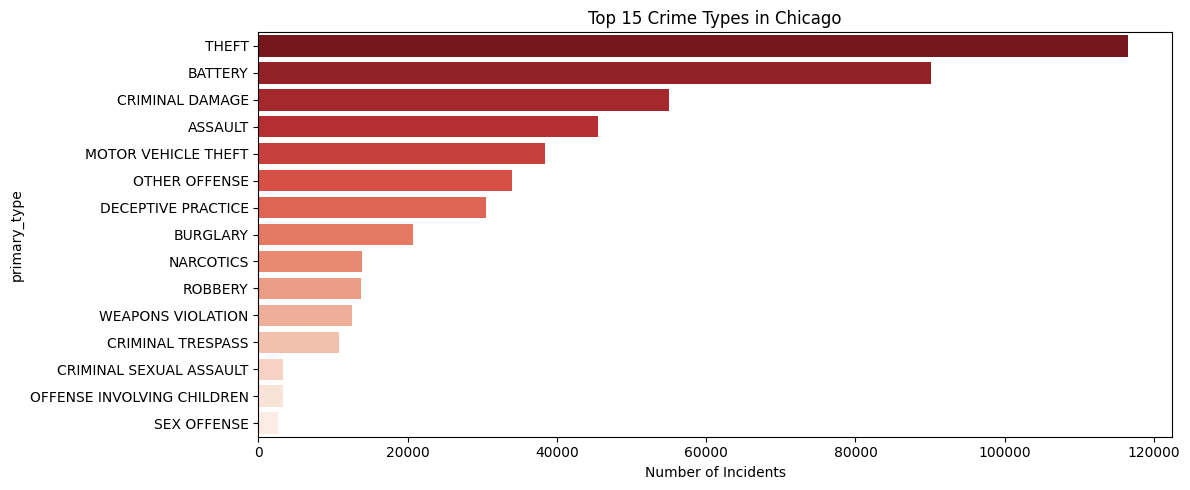


Top 10 crime types:
primary_type
THEFT                  116542
BATTERY                 90132
CRIMINAL DAMAGE         54991
ASSAULT                 45448
MOTOR VEHICLE THEFT     38424
OTHER OFFENSE           34036
DECEPTIVE PRACTICE      30535
BURGLARY                20699
NARCOTICS               13816
ROBBERY                 13761


In [5]:
# Top crime types
top_crimes = df["primary_type"].value_counts().head(15)

plt.figure(figsize=(12, 5))
sns.barplot(x=top_crimes.values, y=top_crimes.index, palette="Reds_r")
plt.xlabel("Number of Incidents")
plt.title("Top 15 Crime Types in Chicago")
plt.tight_layout()
plt.show()

print("\nTop 10 crime types:")
print(top_crimes.head(10).to_string())


In [6]:
#  Parse datetime and add time features
# The API returns lowercase column names\

df.columns = df.columns.str.lower().str.replace(" ", "_")

df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.dropna(subset=["date", "latitude", "longitude"])

df["year"]       = df["date"].dt.year
df["month"]      = df["date"].dt.month
df["day"]        = df["date"].dt.day
df["hour"]       = df["date"].dt.hour
df["dayofweek"]  = df["date"].dt.dayofweek   # 0=Monday
df["week"]       = df["date"].dt.isocalendar().week.astype(int)
df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)

print("Date range in dataset:")
print(f"  From : {df['date'].min()}")
print(f"  To   : {df['date'].max()}")
print(f"\nClean records: {len(df):,}")


Date range in dataset:
  From : 2024-04-22 02:21:00
  To   : 2026-05-17 00:00:00

Clean records: 500,000


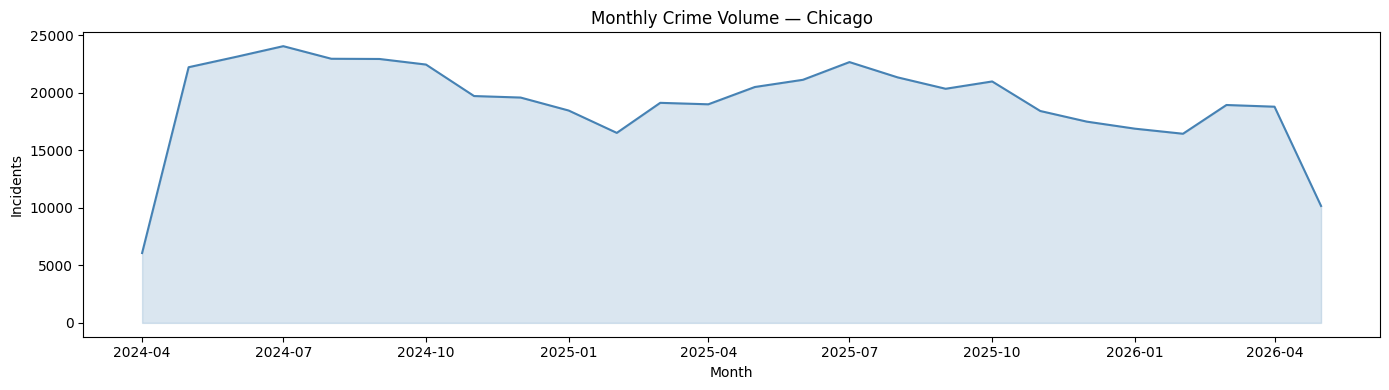

In [7]:
# Crime volume over time (monthly)

monthly = df.groupby(df["date"].dt.to_period("M")).size().reset_index()
monthly.columns = ["period", "count"]
monthly["period_dt"] = monthly["period"].dt.to_timestamp()

plt.figure(figsize=(14, 4))
plt.plot(monthly["period_dt"], monthly["count"], color="steelblue", linewidth=1.5)
plt.fill_between(monthly["period_dt"], monthly["count"], alpha=0.2, color="steelblue")
plt.xlabel("Month")
plt.ylabel("Incidents")
plt.title("Monthly Crime Volume — Chicago")
plt.tight_layout()
plt.show()


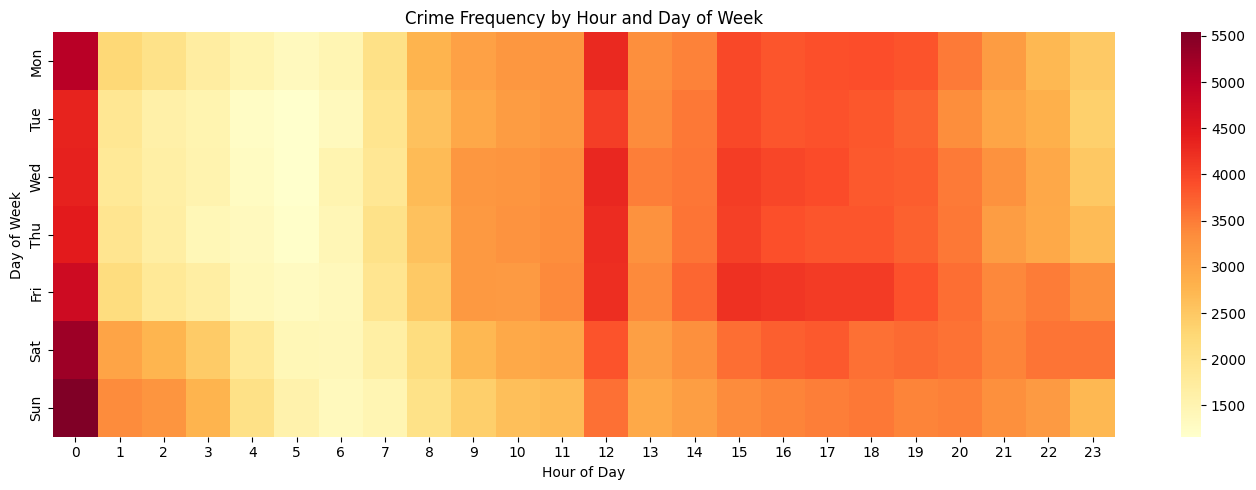

In [8]:
#  Hour-of-day heatmap by weekday
pivot = df.groupby(["dayofweek", "hour"]).size().unstack(fill_value=0)
day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

plt.figure(figsize=(14, 5))
sns.heatmap(pivot, cmap="YlOrRd", linewidths=0,
            xticklabels=range(24), yticklabels=day_labels)
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.title("Crime Frequency by Hour and Day of Week")
plt.tight_layout()
plt.show()


---
## Section 4 — Build a Spatial Grid

Deep learning models like ConvLSTM expect a 2-D spatial grid, not raw GPS
coordinates.  We divide Chicago's bounding box into an N x N grid and assign
every crime incident to a cell.

This converts the problem into: *"How many crimes happened in cell (i, j)
during time window t?"* — a tensor we can feed into sequence models.


In [9]:
# ── Chicago bounding box ─────────────────────────────────────────────────────
LAT_MIN, LAT_MAX =  41.60,  42.05
LON_MIN, LON_MAX = -87.95, -87.50

# Filter to bounding box only
df = df[
    (df["latitude"]  >= LAT_MIN) & (df["latitude"]  <= LAT_MAX) &
    (df["longitude"] >= LON_MIN) & (df["longitude"] <= LON_MAX)
].copy()

print(f"Records inside Chicago bounding box: {len(df):,}")




Records inside Chicago bounding box: 500,000


In [11]:
#  Grid resolution
GRID_SIZE = 20   # 20x20 grid cells
             # Each cell covers roughly 2.5km x 2.5km

df["grid_row"] = pd.cut(df["latitude"],  bins=GRID_SIZE, labels=False)
df["grid_col"] = pd.cut(df["longitude"], bins=GRID_SIZE, labels=False)

df = df.dropna(subset=["grid_row", "grid_col"])
df["grid_row"] = df["grid_row"].astype(int)
df["grid_col"] = df["grid_col"].astype(int)

print(f"Grid size : {GRID_SIZE} x {GRID_SIZE}")
print(f"Cell rows : 0 – {GRID_SIZE-1}")
print(f"Cell cols : 0 – {GRID_SIZE-1}")

Grid size : 20 x 20
Cell rows : 0 – 19
Cell cols : 0 – 19


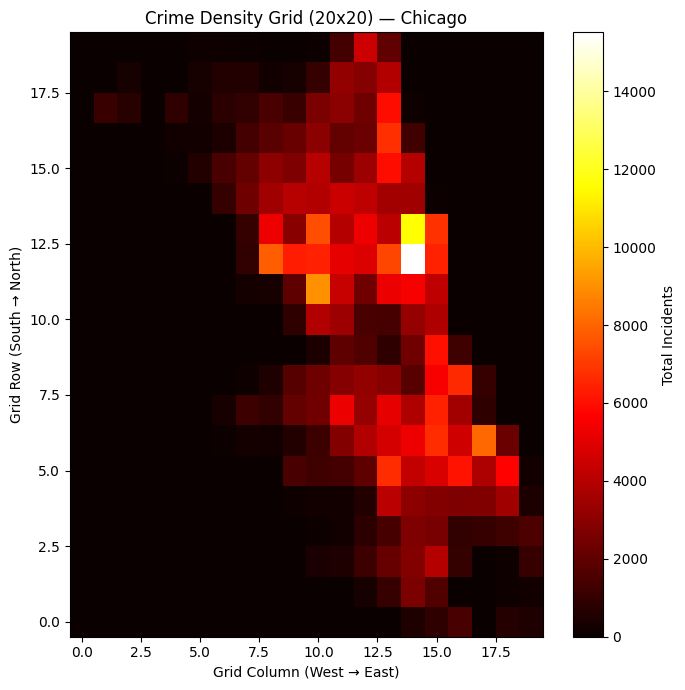

In [12]:
#  Visualise the grid on a static plot
grid_counts = df.groupby(["grid_row", "grid_col"]).size().reset_index(name="count")
grid_matrix = np.zeros((GRID_SIZE, GRID_SIZE))
for _, r in grid_counts.iterrows():
    grid_matrix[int(r["grid_row"]), int(r["grid_col"])] = r["count"]

plt.figure(figsize=(7, 7))
plt.imshow(grid_matrix, cmap="hot", origin="lower", aspect="auto")
plt.colorbar(label="Total Incidents")
plt.xlabel("Grid Column (West → East)")
plt.ylabel("Grid Row (South → North)")
plt.title(f"Crime Density Grid ({GRID_SIZE}x{GRID_SIZE}) — Chicago")
plt.tight_layout()
plt.show()


---
## Section 5 — Interactive Maps with Folium

We create two Folium maps:
1. A static heat-map of all incidents
2. A time-lapse heat-map (HeatMapWithTime) showing monthly crime intensity


In [13]:
#  Map 1: Overall crime heat-map
# Sample 50 000 points so the map loads quickly in a browser
sample = df[["latitude", "longitude"]].dropna().sample(
    min(50_000, len(df)), random_state=SEED
)

m1 = folium.Map(
    location=[41.85, -87.65],
    zoom_start=11,
    tiles="CartoDB dark_matter"
)

HeatMap(
    data=sample.values.tolist(),
    radius=8,
    blur=10,
    min_opacity=0.3,
    gradient={0.2: "blue", 0.4: "lime", 0.6: "yellow", 1.0: "red"}
).add_to(m1)

folium.LayerControl().add_to(m1)
m1.save("map_overall_heatmap.html")
print("Saved: map_overall_heatmap.html")
m1   # Display inline in Jupyter


Saved: map_overall_heatmap.html


In [14]:
#  Map 2: Monthly time-lapse heat-map
# Build a list of coordinate lists, one per month
df["year_month"] = df["date"].dt.to_period("M").astype(str)
periods = sorted(df["year_month"].unique())[-24:]   # last 24 months

heat_data = []
for p in periods:
    subset = df[df["year_month"] == p][["latitude", "longitude"]].dropna()
    # cap at 5000 points per frame for performance
    subset = subset.sample(min(5000, len(subset)), random_state=SEED)
    heat_data.append(subset.values.tolist())

m2 = folium.Map(
    location=[41.85, -87.65],
    zoom_start=11,
    tiles="CartoDB dark_matter"
)

HeatMapWithTime(
    data=heat_data,
    index=periods,
    radius=8,
    blur=10,
    min_opacity=0.3,
    gradient={0.2: "blue", 0.5: "yellow", 1.0: "red"},
    auto_play=True,
    max_speed=5
).add_to(m2)

m2.save("map_monthly_timelapse.html")
print("Saved: map_monthly_timelapse.html")
m2


Saved: map_monthly_timelapse.html


---
## Section 6 — Feature Engineering for Deep Learning

We aggregate crime counts into a **weekly grid tensor**: for each week and each
grid cell we store the total crime count.  

Shape of the resulting tensor: `(num_weeks, GRID_SIZE, GRID_SIZE)`

We also build a flat feature matrix for the LSTM that includes:
- Crime count per cell per week
- Encoded crime type
- Temporal features (week-of-year, year, is_weekend fraction)


In [15]:
# ── Aggregate weekly counts per grid cell
df["year_week"] = df["date"].dt.isocalendar().year.astype(str) + "-W" +                   df["date"].dt.isocalendar().week.astype(str).str.zfill(2)

weekly_grid = (
    df.groupby(["year_week", "grid_row", "grid_col"])
      .size()
      .reset_index(name="count")
)

all_weeks = sorted(weekly_grid["year_week"].unique())
print(f"Total weekly time steps : {len(all_weeks)}")
print(f"First week : {all_weeks[0]}")
print(f"Last week  : {all_weeks[-1]}")


Total weekly time steps : 108
First week : 2024-W17
Last week  : 2026-W20


In [16]:
# Build 3-D tensor  (weeks, rows, cols)
week_index = {w: i for i, w in enumerate(all_weeks)}

crime_tensor = np.zeros((len(all_weeks), GRID_SIZE, GRID_SIZE), dtype=np.float32)

for _, row in weekly_grid.iterrows():
    t = week_index[row["year_week"]]
    r = int(row["grid_row"])
    c = int(row["grid_col"])
    crime_tensor[t, r, c] = row["count"]

print(f"Crime tensor shape : {crime_tensor.shape}")
print(f"  Axis 0 = weeks   : {crime_tensor.shape[0]}")
print(f"  Axis 1 = rows    : {crime_tensor.shape[1]}")
print(f"  Axis 2 = cols    : {crime_tensor.shape[2]}")
print(f"\nMax crimes in a single cell-week : {crime_tensor.max():.0f}")
print(f"Mean crimes per cell-week        : {crime_tensor.mean():.2f}")


Crime tensor shape : (108, 20, 20)
  Axis 0 = weeks   : 108
  Axis 1 = rows    : 20
  Axis 2 = cols    : 20

Max crimes in a single cell-week : 195
Mean crimes per cell-week        : 11.57


In [17]:
#  Normalise the tensor
# We flatten, scale, then reshape so every cell is on the same scale
T, R, C = crime_tensor.shape
flat = crime_tensor.reshape(T, -1)   # (weeks, rows*cols)

scaler = MinMaxScaler()
flat_scaled = scaler.fit_transform(flat)

crime_scaled = flat_scaled.reshape(T, R, C)
print("After scaling — min:", crime_scaled.min(), " max:", crime_scaled.max())


After scaling — min: 0.0  max: 1.0000001


In [18]:
#  Create sliding-window sequences
# Given the last SEQ_LEN weeks, predict the next week's grid
SEQ_LEN    = 8    # look back 8 weeks
PRED_STEPS = 1    # forecast 1 week ahead

X_list, y_list = [], []

for t in range(SEQ_LEN, T - PRED_STEPS + 1):
    X_list.append(crime_scaled[t - SEQ_LEN : t])      # (SEQ_LEN, R, C)
    y_list.append(crime_scaled[t : t + PRED_STEPS])   # (PRED_STEPS, R, C)

X = np.array(X_list)   # (samples, SEQ_LEN, R, C)
y = np.array(y_list)   # (samples, PRED_STEPS, R, C)

print(f"X shape : {X.shape}   — (samples, sequence_length, rows, cols)")
print(f"y shape : {y.shape}   — (samples, pred_steps,  rows, cols)")

# ── Train / validation / test split (70 / 15 / 15) ───────────────────────────
n = len(X)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

X_train, y_train = X[:train_end],  y[:train_end]
X_val,   y_val   = X[train_end:val_end], y[train_end:val_end]
X_test,  y_test  = X[val_end:],    y[val_end:]

print(f"\nSplit sizes  — train: {len(X_train)}  val: {len(X_val)}  test: {len(X_test)}")


X shape : (100, 8, 20, 20)   — (samples, sequence_length, rows, cols)
y shape : (100, 1, 20, 20)   — (samples, pred_steps,  rows, cols)

Split sizes  — train: 70  val: 15  test: 15


---
## Section 7 — PyTorch Dataset and DataLoader

PyTorch expects data wrapped in a `Dataset` class.  We write a simple one that
returns `(X, y)` tensors and then wrap it in a `DataLoader` that handles
batching and shuffling automatically.


In [19]:
class CrimeDataset(Dataset):
    """
    Wraps numpy arrays into a PyTorch-compatible Dataset.
    Each item is (input_sequence, target_grid).
    """
    def __init__(self, X, y):
        # Convert to float32 tensors right away
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# ── DataLoaders ───────────────────────────────────────────────────────────────
BATCH_SIZE = 16

train_loader = DataLoader(CrimeDataset(X_train, y_train),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(CrimeDataset(X_val,   y_val),
                          batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(CrimeDataset(X_test,  y_test),
                          batch_size=BATCH_SIZE, shuffle=False)

# Quick sanity check
sample_x, sample_y = next(iter(train_loader))
print(f"Batch X shape : {sample_x.shape}")   # (batch, seq_len, R, C)
print(f"Batch y shape : {sample_y.shape}")   # (batch, pred_steps, R, C)


Batch X shape : torch.Size([16, 8, 20, 20])
Batch y shape : torch.Size([16, 1, 20, 20])


---
## Section 8 — Model 1: Spatial-LSTM

**Idea:** Flatten each week's grid into a 1-D vector, pass the sequence of
vectors through an LSTM, then decode the hidden state back into a full grid.

This is the simpler of the two models.  It captures the temporal patterns but
treats space as a flat feature (it does not understand spatial neighbours).

Architecture:
```
Input  (batch, seq_len, R*C)
  → LSTM   (hidden_size=128, num_layers=2)
  → Dropout(0.3)
  → Linear (R*C)
Output (batch, 1, R*C)  → reshape → (batch, 1, R, C)
```


In [20]:
class SpatialLSTM(nn.Module):
    """
    Spatial-LSTM: flattens the grid at each time step, runs an LSTM,
    then decodes back to a full grid.
    """
    def __init__(self, grid_rows, grid_cols,
                 hidden_size=128, num_layers=2, dropout=0.3):
        super().__init__()
        self.grid_rows  = grid_rows
        self.grid_cols  = grid_cols
        self.input_size = grid_rows * grid_cols   # flattened grid

        self.lstm = nn.LSTM(
            input_size  = self.input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,      # input shape: (batch, seq, features)
            dropout     = dropout if num_layers > 1 else 0.0
        )

        self.dropout = nn.Dropout(dropout)

        self.decoder = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.ReLU(),
            nn.Linear(256, self.input_size),
            nn.Sigmoid()   # output is normalised [0, 1]
        )

    def forward(self, x):
        # x: (batch, seq_len, R, C)
        batch, seq, R, C = x.shape
        x_flat = x.view(batch, seq, R * C)          # flatten spatial dims

        _, (hidden, _) = self.lstm(x_flat)          # use final hidden state
        out = self.dropout(hidden[-1])               # last layer's state
        out = self.decoder(out)                      # (batch, R*C)
        out = out.view(batch, 1, R, C)               # restore spatial shape
        return out


# ── Instantiate ───────────────────────────────────────────────────────────────
lstm_model = SpatialLSTM(
    grid_rows   = GRID_SIZE,
    grid_cols   = GRID_SIZE,
    hidden_size = 128,
    num_layers  = 2,
    dropout     = 0.3
).to(DEVICE)

total_params = sum(p.numel() for p in lstm_model.parameters())
print(f"SpatialLSTM — total parameters: {total_params:,}")
print(lstm_model)


SpatialLSTM — total parameters: 539,280
SpatialLSTM(
  (lstm): LSTM(400, 128, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (decoder): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=400, bias=True)
    (3): Sigmoid()
  )
)


---
## Section 9 — Model 2: ConvLSTM (Spatio-Temporal)

**Idea:** Instead of flattening the grid, we apply convolutions inside the
LSTM gates so the model learns spatial patterns (nearby cells influencing each
other) AND temporal patterns at the same time.

This is the proper spatio-temporal model.  We implement a single ConvLSTM cell
from scratch and stack it into a small network.

Architecture:
```
Input  (batch, seq_len, 1, R, C)   ← treat grid as single-channel image
  → ConvLSTM cell (kernel 3x3, filters=32)
  → Conv2d (32 → 1, kernel 1x1)
  → Sigmoid
Output (batch, 1, R, C)
```


In [21]:
class ConvLSTMCell(nn.Module):
    """
    A single ConvLSTM cell.  The standard LSTM gating equations but
    matrix multiplications are replaced with 2-D convolutions.

    This lets the cell consider spatial context (neighbouring grid cells)
    when deciding what to remember or forget.
    """
    def __init__(self, in_channels, hidden_channels, kernel_size=3):
        super().__init__()
        self.hidden_channels = hidden_channels
        pad = kernel_size // 2  # 'same' padding

        # One conv that computes all four gates at once
        self.conv = nn.Conv2d(
            in_channels  = in_channels + hidden_channels,
            out_channels = 4 * hidden_channels,   # i, f, g, o
            kernel_size  = kernel_size,
            padding      = pad
        )

    def forward(self, x, h, c):
        # x: (batch, in_channels, R, C)
        # h: (batch, hidden_channels, R, C)
        combined = torch.cat([x, h], dim=1)   # concat along channel axis

        gates = self.conv(combined)           # (batch, 4*hidden, R, C)
        i, f, g, o = gates.chunk(4, dim=1)   # split into 4 equal chunks

        i = torch.sigmoid(i)    # input gate
        f = torch.sigmoid(f)    # forget gate
        g = torch.tanh(g)       # cell gate
        o = torch.sigmoid(o)    # output gate

        c_next = f * c + i * g
        h_next = o * torch.tanh(c_next)
        return h_next, c_next

    def init_hidden(self, batch_size, spatial_size):
        H, W = spatial_size
        zeros = torch.zeros(batch_size, self.hidden_channels, H, W, device=DEVICE)
        return zeros, zeros   # (h_0, c_0)


class ConvLSTMForecaster(nn.Module):
    """
    Wraps the ConvLSTMCell into a sequence model, then uses a 1x1 conv
    to compress the hidden channels into a single-channel prediction.
    """
    def __init__(self, in_channels=1, hidden_channels=32, kernel_size=3):
        super().__init__()
        self.cell = ConvLSTMCell(in_channels, hidden_channels, kernel_size)
        self.head  = nn.Sequential(
            nn.Conv2d(hidden_channels, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 1, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # x: (batch, seq_len, R, C)  — no channel dim yet
        batch, seq, R, C = x.shape

        # Add channel dimension: (batch, seq_len, 1, R, C)
        x = x.unsqueeze(2)

        h, c = self.cell.init_hidden(batch, (R, C))

        for t in range(seq):
            h, c = self.cell(x[:, t], h, c)   # step through sequence

        pred = self.head(h)                    # (batch, 1, R, C)
        return pred.unsqueeze(1)               # (batch, 1, 1, R, C) → squeeze later


# ── Instantiate ───────────────────────────────────────────────────────────────
convlstm_model = ConvLSTMForecaster(
    in_channels     = 1,
    hidden_channels = 32,
    kernel_size     = 3
).to(DEVICE)

total_params = sum(p.numel() for p in convlstm_model.parameters())
print(f"ConvLSTMForecaster — total parameters: {total_params:,}")
print(convlstm_model)


ConvLSTMForecaster — total parameters: 42,785
ConvLSTMForecaster(
  (cell): ConvLSTMCell(
    (conv): Conv2d(33, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (head): Sequential(
    (0): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 1, kernel_size=(1, 1), stride=(1, 1))
    (3): Sigmoid()
  )
)


---
## Section 10 — Training Loop

We write a reusable training function.  It runs for a given number of epochs,
evaluates on the validation set each epoch, and saves the best model weights
based on validation loss.  We use Mean Squared Error as the loss function.


In [24]:
import numpy as np
import torch
import torch.nn as nn
import math

def train_model(model, train_loader, val_loader,
                epochs=30, lr=1e-3, model_name="model"):

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=1e-4
    )

    # FIXED: removed verbose (not supported in new PyTorch)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        patience=5,
        factor=0.5
    )

    criterion = nn.MSELoss()

    best_val_loss = float("inf")
    best_path = f"{model_name}_best.pt"

    history = {
        "train_loss": [],
        "val_loss": []
    }

    for epoch in range(1, epochs + 1):

        # ======================
        # TRAINING
        # ======================
        model.train()
        train_losses = []

        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()

            pred = model(xb)

            # FIX shape safety
            pred = pred.squeeze()
            yb = yb.squeeze()

            loss = criterion(pred, yb)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()

            train_losses.append(loss.item())

        # ======================
        # VALIDATION
        # ======================
        model.eval()
        val_losses = []

        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)

                pred = model(xb).squeeze()
                yb = yb.squeeze()

                loss = criterion(pred, yb)
                val_losses.append(loss.item())

        train_loss = np.mean(train_losses)
        val_loss = np.mean(val_losses)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        scheduler.step(val_loss)

        # SAVE BEST MODEL
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_path)

        # PRINT PROGRESS
        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch {epoch:03d}/{epochs} | "
                  f"Train: {train_loss:.5f} | Val: {val_loss:.5f}")

    print("\nBest validation loss:", best_val_loss)
    print("Saved model:", best_path)

    model.load_state_dict(torch.load(best_path))
    return history

---
## Section 11 — Train the Spatial-LSTM


In [26]:
print("=" * 50)
print("Training SpatialLSTM")
print("=" * 50)

lstm_history = train_model(
    model=lstm_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=40,
    lr=1e-3,
    model_name="spatial_lstm"
)

Training SpatialLSTM
Epoch 001/40 | Train: 0.15222 | Val: 0.15085
Epoch 005/40 | Train: 0.02533 | Val: 0.02635
Epoch 010/40 | Train: 0.02240 | Val: 0.02179
Epoch 015/40 | Train: 0.02194 | Val: 0.02456
Epoch 020/40 | Train: 0.02124 | Val: 0.02335
Epoch 025/40 | Train: 0.02166 | Val: 0.02309
Epoch 030/40 | Train: 0.02157 | Val: 0.02369
Epoch 035/40 | Train: 0.02158 | Val: 0.02311
Epoch 040/40 | Train: 0.02128 | Val: 0.02340

Best validation loss: 0.02179410494863987
Saved model: spatial_lstm_best.pt


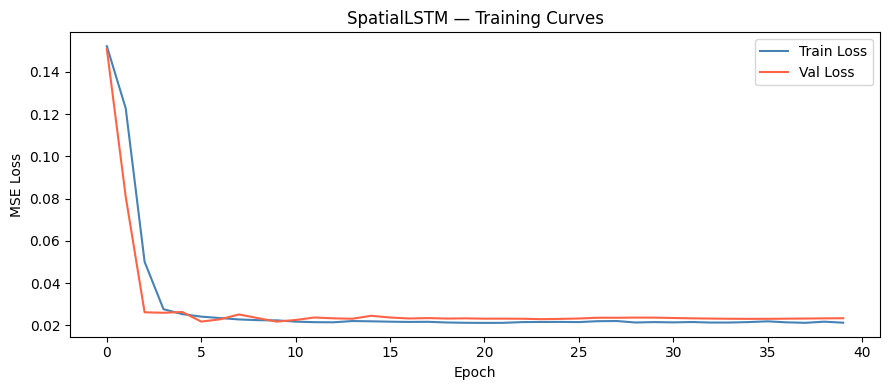

In [27]:
# ── Plot training curves ──────────────────────────────────────────────────────
def plot_history(history, title):
    plt.figure(figsize=(9, 4))
    plt.plot(history["train_loss"], label="Train Loss", color="steelblue")
    plt.plot(history["val_loss"],   label="Val Loss",   color="tomato")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_history(lstm_history, "SpatialLSTM — Training Curves")


---
## Section 12 — Train the ConvLSTM


In [28]:
print("="*55)
print("Training ConvLSTMForecaster")
print("="*55)

convlstm_history = train_model(
    model        = convlstm_model,
    train_loader = train_loader,
    val_loader   = val_loader,
    epochs       = 40,
    lr           = 5e-4,
    model_name   = "convlstm"
)


Training ConvLSTMForecaster
Epoch 001/40 | Train: 0.13933 | Val: 0.14332
Epoch 005/40 | Train: 0.11659 | Val: 0.09223
Epoch 010/40 | Train: 0.07051 | Val: 0.05092
Epoch 015/40 | Train: 0.06545 | Val: 0.04635
Epoch 020/40 | Train: 0.05873 | Val: 0.03908
Epoch 025/40 | Train: 0.03025 | Val: 0.02443
Epoch 030/40 | Train: 0.02974 | Val: 0.02611
Epoch 035/40 | Train: 0.02897 | Val: 0.02442
Epoch 040/40 | Train: 0.02868 | Val: 0.02370

Best validation loss: 0.023642025887966156
Saved model: convlstm_best.pt


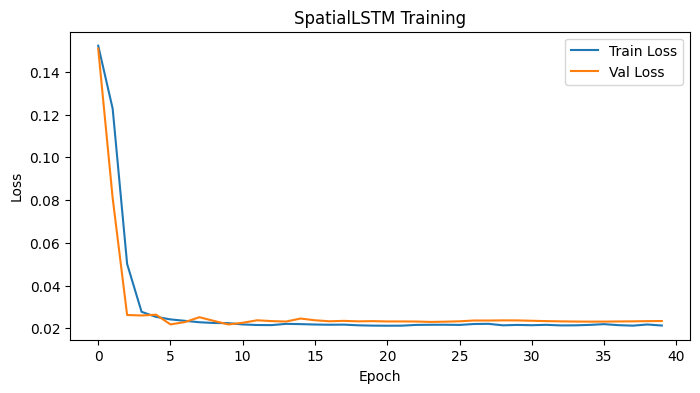

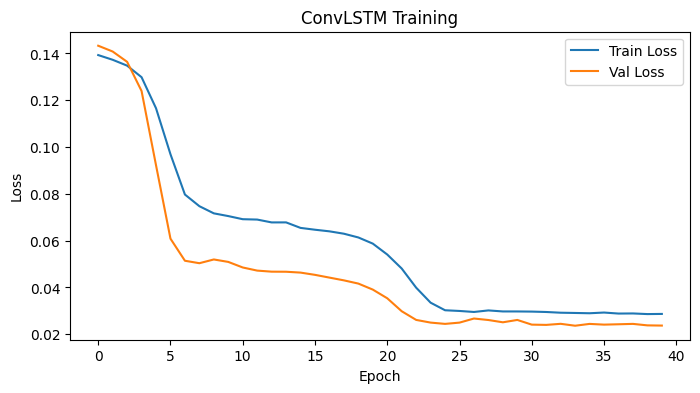

In [29]:

def plot_history(history, title):
    plt.figure(figsize=(8, 4))
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()


plot_history(lstm_history, "SpatialLSTM Training")
plot_history(convlstm_history, "ConvLSTM Training")


---
## Section 13 — Evaluate on Test Set

We measure performance using:
- **MAE** (Mean Absolute Error) — average absolute difference
- **RMSE** (Root Mean Squared Error) — penalises large errors more
- **R²** — how much variance our model explains (1.0 is perfect)

Results are computed on the *inverse-scaled* values so they are interpretable
in real crime-count units.


In [31]:
def evaluate_model(model, loader, model_name="Model"):
    """
    Evaluate model and safely handle different output shapes
    (SpatialLSTM vs ConvLSTM).
    """

    model.eval()
    all_preds, all_targets = [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)

            pred = model(xb).cpu().numpy()
            tgt  = yb.cpu().numpy()

            all_preds.append(pred)
            all_targets.append(tgt)

    preds   = np.concatenate(all_preds, axis=0)
    targets = np.concatenate(all_targets, axis=0)

    # ==============================
    # FIX: STANDARDIZE SHAPES
    # ==============================

    # Remove extra dimensions safely
    preds = np.squeeze(preds)
    targets = np.squeeze(targets)

    # Now enforce (N, R, C)
    if len(preds.shape) == 2:
        preds = preds[:, :, None]
        targets = targets[:, :, None]

    N = preds.shape[0]
    R = preds.shape[1]
    C = preds.shape[2]

    # inverse scaling
    preds_inv = scaler.inverse_transform(
        preds.reshape(N, -1)
    ).reshape(N, R, C)

    targets_inv = scaler.inverse_transform(
        targets.reshape(N, -1)
    ).reshape(N, R, C)

    # metrics
    mae = mean_absolute_error(
        targets_inv.flatten(),
        preds_inv.flatten()
    )

    rmse = math.sqrt(
        mean_squared_error(
            targets_inv.flatten(),
            preds_inv.flatten()
        )
    )

    ss_res = np.sum((targets_inv - preds_inv) ** 2)
    ss_tot = np.sum((targets_inv - targets_inv.mean()) ** 2)
    r2 = 1 - ss_res / (ss_tot + 1e-8)

    print(model_name)
    print(f"  MAE  : {mae:.3f}")
    print(f"  RMSE : {rmse:.3f}")
    print(f"  R2   : {r2:.4f}")

    return preds_inv, targets_inv

In [32]:
lstm_preds, lstm_targets = evaluate_model(
    lstm_model,
    test_loader,
    "SpatialLSTM"
)

convlstm_preds, convlstm_targets = evaluate_model(
    convlstm_model,
    test_loader,
    "ConvLSTMForecaster"
)

SpatialLSTM
  MAE  : 2.307
  RMSE : 4.793
  R2   : 0.9308
ConvLSTMForecaster
  MAE  : 2.279
  RMSE : 4.691
  R2   : 0.9337


---
## Section 14 — Visualise Predictions vs Ground Truth

We pick the first test-set week and show the actual crime grid next to both
model predictions side by side.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

vmax = max(lstm_targets[0].max(), lstm_preds[0].max(), convlstm_preds[0].max())

def show_grid(ax, grid, title, vmax):
    im = ax.imshow(grid, cmap="hot", origin="lower",
                   aspect="auto", vmin=0, vmax=vmax)
    plt.colorbar(im, ax=ax, label="Predicted crimes")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Grid Column")
    ax.set_ylabel("Grid Row")

show_grid(axes[0], lstm_targets[0],    "Ground Truth",        vmax)
show_grid(axes[1], lstm_preds[0],      "SpatialLSTM Pred",   vmax)
show_grid(axes[2], convlstm_preds[0],  "ConvLSTM Pred",      vmax)

plt.suptitle("Predicted vs Actual Crime Grid — First Test Week",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
# ── Difference map: error per cell ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

err_lstm    = np.abs(lstm_preds[0]    - lstm_targets[0])
err_convlstm = np.abs(convlstm_preds[0] - convlstm_targets[0])
vmax_err = max(err_lstm.max(), err_convlstm.max())

for ax, err, title in zip(axes,
                           [err_lstm, err_convlstm],
                           ["SpatialLSTM — Absolute Error",
                            "ConvLSTM — Absolute Error"]):
    im = ax.imshow(err, cmap="RdYlGn_r", origin="lower",
                   aspect="auto", vmin=0, vmax=vmax_err)
    plt.colorbar(im, ax=ax, label="Error (crimes)")
    ax.set_title(title, fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()


---
## Section 15 — Forecast Heat-Map on Folium

We convert the ConvLSTM's forecast grid back to GPS coordinates and plot it
as an interactive Folium heat-map.  This is what would power a real-world
crime-prediction dashboard.


In [33]:
# ── Convert grid prediction to lat/lon heat-map data ─────────────────────────
lat_edges = np.linspace(LAT_MIN, LAT_MAX, GRID_SIZE + 1)
lon_edges = np.linspace(LON_MIN, LON_MAX, GRID_SIZE + 1)

lat_centers = (lat_edges[:-1] + lat_edges[1:]) / 2
lon_centers = (lon_edges[:-1] + lon_edges[1:]) / 2

forecast_grid = convlstm_preds[0]   # shape (R, C)

# Build list of [lat, lon, weight] for HeatMap
heat_points = []
for r in range(GRID_SIZE):
    for c in range(GRID_SIZE):
        weight = float(forecast_grid[r, c])
        if weight > 0:
            heat_points.append([lat_centers[r], lon_centers[c], weight])

# ── Build the forecast map ────────────────────────────────────────────────────
m3 = folium.Map(
    location=[41.85, -87.65],
    zoom_start=11,
    tiles="CartoDB dark_matter"
)

HeatMap(
    data       = heat_points,
    radius     = 25,
    blur       = 20,
    min_opacity= 0.3,
    max_zoom   = 15,
    gradient   = {0.2: "blue", 0.5: "lime", 0.8: "yellow", 1.0: "red"}
).add_to(m3)

# Mark top-5 highest-risk cells
top5_idx = sorted(range(len(heat_points)),
                  key=lambda i: heat_points[i][2], reverse=True)[:5]

for rank, idx in enumerate(top5_idx, 1):
    lat, lon, w = heat_points[idx]
    folium.CircleMarker(
        location=[lat, lon],
        radius=12,
        color="white",
        fill=True,
        fill_color="red",
        fill_opacity=0.9,
        popup=f"Risk Rank #{rank}<br>Predicted: {w:.1f} crimes"
    ).add_to(m3)

folium.LayerControl().add_to(m3)
m3.save("map_forecast.html")
print("Saved: map_forecast.html")
m3


Saved: map_forecast.html


---
## Section 16 — Model Comparison

A side-by-side bar chart comparing both models on all three metrics.


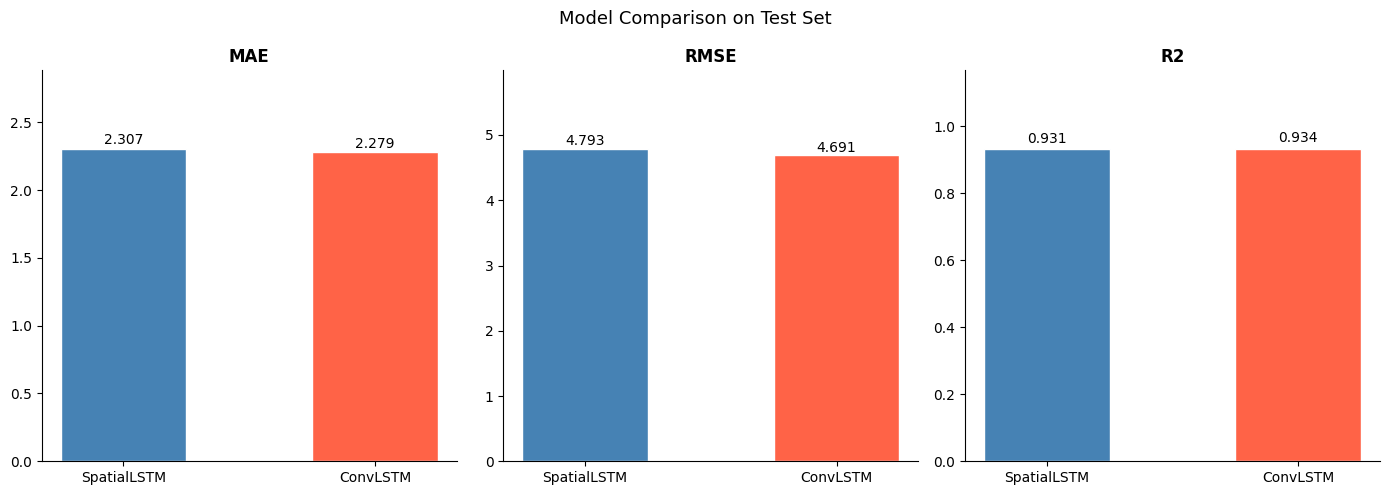

In [34]:
import math as _math

def get_metrics(preds, targets):
    mae  = mean_absolute_error(targets.flatten(), preds.flatten())
    rmse = _math.sqrt(mean_squared_error(targets.flatten(), preds.flatten()))
    ss_res = np.sum((targets - preds) ** 2)
    ss_tot = np.sum((targets - targets.mean()) ** 2)
    r2 = 1 - ss_res / (ss_tot + 1e-8)
    return mae, rmse, r2

lstm_mae,     lstm_rmse,     lstm_r2     = get_metrics(lstm_preds,     lstm_targets)
convlstm_mae, convlstm_rmse, convlstm_r2 = get_metrics(convlstm_preds, convlstm_targets)

metrics = {
    "MAE":  [lstm_mae,     convlstm_mae],
    "RMSE": [lstm_rmse,    convlstm_rmse],
    "R2":   [lstm_r2,      convlstm_r2],
}

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
models = ["SpatialLSTM", "ConvLSTM"]
colors = ["steelblue", "tomato"]

for ax, (metric, vals) in zip(axes, metrics.items()):
    bars = ax.bar(models, vals, color=colors, edgecolor="white", width=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{val:.3f}", ha="center", va="bottom", fontsize=10)
    ax.set_title(metric, fontsize=12, fontweight="bold")
    ax.set_ylim(0, max(vals) * 1.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("Model Comparison on Test Set", fontsize=13)
plt.tight_layout()
plt.show()


---
## Section 17 — Save Models and Artefacts

We save both model checkpoints so they can be loaded later for the web app
without retraining.


In [35]:
import json

# Save final model weights
torch.save(lstm_model.state_dict(),    "spatial_lstm_final.pt")
torch.save(convlstm_model.state_dict(), "convlstm_final.pt")

# Save scaler params for inference later
import pickle
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Save grid config
config = {
    "GRID_SIZE": GRID_SIZE,
    "SEQ_LEN":   SEQ_LEN,
    "LAT_MIN":   LAT_MIN,
    "LAT_MAX":   LAT_MAX,
    "LON_MIN":   LON_MIN,
    "LON_MAX":   LON_MAX,
}
with open("grid_config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Saved artefacts:")
print("  spatial_lstm_final.pt")
print("  convlstm_final.pt")
print("  scaler.pkl")
print("  grid_config.json")
print("  map_overall_heatmap.html")
print("  map_monthly_timelapse.html")
print("  map_forecast.html")


Saved artefacts:
  spatial_lstm_final.pt
  convlstm_final.pt
  scaler.pkl
  grid_config.json
  map_overall_heatmap.html
  map_monthly_timelapse.html
  map_forecast.html


---
## Section 18 — Summary and Next Steps

**What we built:**

| Step | What we did |
|------|-------------|
| Data | Loaded 500 k crime records from Chicago Open Data portal |
| EDA | Explored crime types, hourly/weekly patterns, spatial density |
| Grid | Divided Chicago into a 20x20 spatial grid |
| Maps | Built static, time-lapse, and forecast Folium heat-maps |
| LSTM | Trained a Spatial-LSTM that flattens the grid per timestep |
| ConvLSTM | Trained a proper spatio-temporal ConvLSTM with learned spatial kernels |
| Eval | Compared both models on MAE, RMSE, and R² |

**Ideas for improvement:**
- Increase grid resolution (40x40 or 64x64) for finer spatial detail
- Add weather data, school calendars, or event data as exogenous features
- Use a multi-step prediction horizon (forecast next 4 weeks)
- Try a Graph Neural Network (GNN) to model road-network topology
- Add crime-type-specific models for THEFT, ASSAULT, etc.




---

---